# Per-method evaluation for the poster

Evaluates each of the 6 methods *individually* (not the consensus) against
ground truth, so you can show "here's how syntactic vs semantic methods
compare on their own" rather than just the final blended result.

Semantic: `algorithm_1` (SapBERT, query only), `algorithm_2` (BioLORD,
query+context), `algorithm_ai` (BioLORD, AI-generated context)
Syntactic: `multi_match` (BM25), `elastic_fuzzy` (BM25+fuzzy), `jaccard`
(n-gram overlap)

Same hit@k + hierarchy-aware scoring as `evaluate_final_candidates.ipynb`,
applied per-method instead of to the final consensus.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from functools import lru_cache

from concept_normalisation import config


pd.set_option("display.max_colwidth", None)

# ICD-9

## Load data + ground truth

In [2]:
# Explicit ICD-9 files
ICD9_TABLE = config.DATA_DIR / "diagnosis_icd9_snomed.csv"
ICD9_CHECKPOINT = config.OUTPUT_DIR / "diagnosis_icd9_snomed_pipeline_checkpoint.parquet"

# Load pipeline results
data = pd.read_parquet(ICD9_CHECKPOINT)
ground_truth = pd.read_csv(ICD9_TABLE, dtype={"icd9": str, "snomed": str})

# Make sure codes are strings
data["icd9"] = data["icd9"].astype(str).str.strip()
ground_truth["icd9"] = ground_truth["icd9"].astype(str).str.strip()
ground_truth["snomed"] = ground_truth["snomed"].astype(str).str.strip()

# ICD-9 -> all valid SNOMED codes
valid_snomed_by_icd = (
    ground_truth.dropna(subset=["icd9", "snomed"]).groupby("icd9")["snomed"].apply(set)
)

# Attach valid SNOMED codes
data["valid_snomed_codes"] = data["icd9"].map(valid_snomed_by_icd)

# Sanity checks
print("Rows:", len(data))
print("Checkpoint:", ICD9_CHECKPOINT)
print("Ground truth:", ICD9_TABLE)
print("Missing ICD-9:", data["icd9"].isna().sum())
print("Missing valid SNOMED sets:", data["valid_snomed_codes"].isna().sum())
print("\nColumns:")
print(data.columns.tolist())

Rows: 6356
Checkpoint: /Users/kirke/ML_etc/concept-normalisation/data/output/diagnosis_icd9_snomed_pipeline_checkpoint.parquet
Ground truth: /Users/kirke/ML_etc/concept-normalisation/data/diagnosis_icd9_snomed.csv
Missing ICD-9: 0
Missing valid SNOMED sets: 701

Columns:
['diagnosisid', 'patientunitstayid', 'activeupondischarge', 'diagnosisoffset', 'diagnosisstring', 'diagnosispriority', 'icd9', 'snomed', 'diagnosis_text', 'algorithm_1_text', 'algorithm_2_text', 'algorithm_ai_metadata', 'algorithm_1_matches', 'algorithm_2_matches', 'algorithm_ai_text', 'algorithm_ai_matches', 'multi_match_matches', 'elastic_fuzzy_matches', 'jaccard_matches', 'valid_snomed_codes']


In [3]:
print(data[["diagnosis_text", "icd9", "snomed"]].head())

                                                                          diagnosis_text  \
0                                 cardiovascular - arrhythmias - ventricular tachycardia   
1                                     cardiovascular - arrhythmias - atrial fibrillation   
2                                                   endocrine - thyroid - hypothyroidism   
3  gastrointestinal - hepatic disease - hepatic dysfunction - with cirrhosis - alcoholic   
4                            gastrointestinal - hepatic disease - hepatic encephalopathy   

     icd9              snomed  
0   427.1             3424008  
1  427.31  129032061000119103  
2   244.9     135781000119105  
3   571.2    1082601000119104  
4   572.2  232534061000119102  


## Hierarchy (for the hierarchy-aware score)

In [4]:
from concept_normalisation.ranking.hierarchy import SnomedHierarchy

hierarchy = SnomedHierarchy(relationship_file=config.RELATIONSHIP_FILE)
hierarchy.load()


@lru_cache(maxsize=None)
def cached_ancestors(concept_id, max_depth):
    return frozenset(hierarchy.get_ancestors(concept_id, max_depth=max_depth))


def hierarchy_related(a, b, max_depth):
    if a == b:
        return True
    return b in cached_ancestors(a, max_depth) or a in cached_ancestors(b, max_depth)

Loading SNOMED relationships from /Users/kirke/ML_etc/concept-normalisation/data/SnomedCT_InternationalRF2_PRODUCTION_20260601T120000Z/Snapshot/Terminology/sct2_Relationship_Snapshot_INT_20260601.txt...
Active 'Is a' relationships: 635,106


## Scoring functions

Same definitions as `evaluate_final_candidates.ipynb` -- one hit@k
function per row, applied per method column below.

In [5]:
def extract_concept_ids(matches, k):
    if not isinstance(matches, (list, tuple)) and not hasattr(matches, "__len__"):
        return []
    matches = list(matches)[:k]
    return [str(m["concept_id"]) for m in matches if isinstance(m, dict) and "concept_id" in m]


def hit_at_k(matches, valid_codes, k):
    if not isinstance(valid_codes, set):
        return False
    candidates = set(extract_concept_ids(matches, k))
    return bool(candidates & valid_codes)


def hit_at_k_hierarchy(matches, valid_codes, k, max_depth):
    if not isinstance(valid_codes, set):
        return False
    candidates = extract_concept_ids(matches, k)
    return any(
        hierarchy_related(candidate, valid_code, max_depth)
        for candidate in candidates
        for valid_code in valid_codes
    )

## Evaluate every method

In [6]:
METHODS = {
    "algorithm_1": ("semantic", "algorithm_1_matches"),
    "algorithm_2": ("semantic", "algorithm_2_matches"),
    "algorithm_ai": ("semantic", "algorithm_ai_matches"),
    "multi_match": ("syntactic", "multi_match_matches"),
    "elastic_fuzzy": ("syntactic", "elastic_fuzzy_matches"),
    "jaccard": ("syntactic", "jaccard_matches"),
}

MAX_DEPTH = 3  # hierarchy tolerance, matches evaluate_final_candidates.ipynb

rows = []
for method_name, (method_type, column) in METHODS.items():
    if column not in data.columns:
        print(f"Skipping {method_name}: {column} not in data (method wasn't run)")
        continue

    row = {"method": method_name, "type": method_type}
    for k in [1, 5]:
        row[f"strict_hit@{k}"] = data.apply(
            lambda r: hit_at_k(r[column], r["valid_snomed_codes"], k), axis=1
        ).mean()
        row[f"hierarchy_hit@{k}"] = data.apply(
            lambda r: hit_at_k_hierarchy(r[column], r["valid_snomed_codes"], k, MAX_DEPTH), axis=1
        ).mean()
    rows.append(row)

method_scores = pd.DataFrame(rows)
method_scores

,method,type,strict_hit@1,hierarchy_hit@1,strict_hit@5,hierarchy_hit@5
0,algorithm_1,semantic,0.042480,0.235525,0.070799,0.249371
1,algorithm_2,semantic,0.042165,0.187697,0.429673,0.643958
2,algorithm_ai,semantic,0.061989,0.621460,0.100850,0.673537
3,multi_match,syntactic,0.065765,0.188798,0.475614,0.595500
4,elastic_fuzzy,syntactic,0.107930,0.142700,0.503304,0.643801
5,jaccard,syntactic,0.000315,0.071114,0.000315,0.461611


## Poster chart

Grouped bar chart, semantic methods on the left, syntactic on the right,
exact hit@5 and hierarchy-aware hit@5 side by side per method.

Saved: /Users/kirke/ML_etc/concept-normalisation/data/output/poster_method_comparison.png


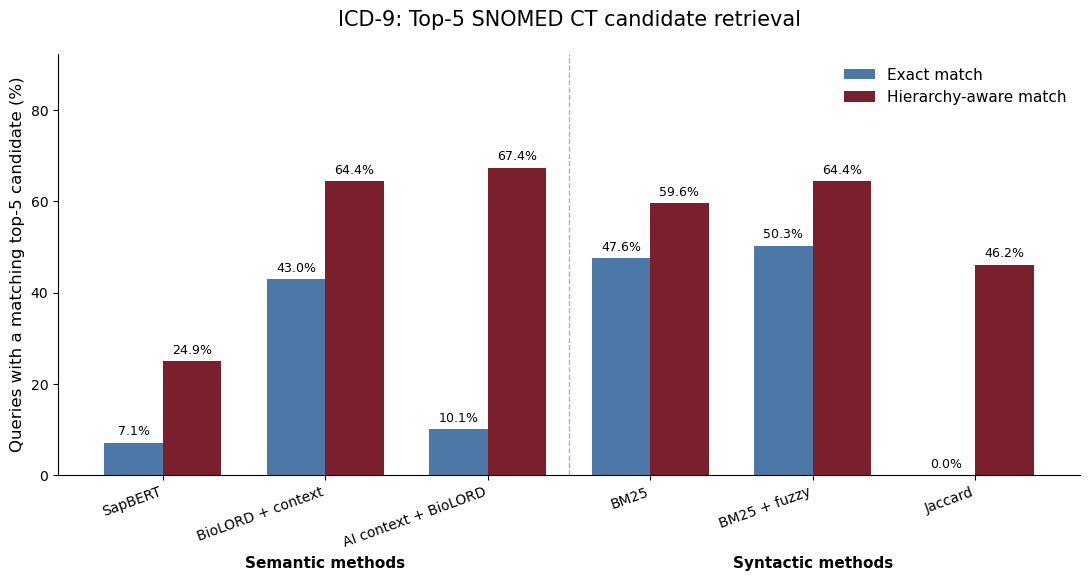

In [7]:
label_map = {
    "algorithm_1": "SapBERT",
    "algorithm_2": "BioLORD + context",
    "algorithm_ai": "AI context + BioLORD",
    "multi_match": "BM25",
    "elastic_fuzzy": "BM25 + fuzzy",
    "jaccard": "Jaccard",
}
method_order = ["algorithm_1", "algorithm_2", "algorithm_ai", "multi_match", "elastic_fuzzy", "jaccard"]

plot_data = method_scores.copy()
plot_data["label"] = plot_data["method"].map(label_map)
plot_data["method"] = pd.Categorical(plot_data["method"], categories=method_order, ordered=True)
plot_data = plot_data.sort_values("method").reset_index(drop=True)

x = np.arange(len(plot_data))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 6))

bars_exact = ax.bar(x - width / 2, plot_data["strict_hit@5"] * 100, width, label="Exact match", color="#4C78A8")
bars_hierarchy = ax.bar(x + width / 2, plot_data["hierarchy_hit@5"] * 100, width, label="Hierarchy-aware match", color="#7A1F2B")

ax.set_ylabel("Queries with a matching top-5 candidate (%)", fontsize=12)
ax.set_title("ICD-9: Top-5 SNOMED CT candidate retrieval", fontsize=15, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(plot_data["label"], rotation=20, ha="right")

for bars in (bars_exact, bars_hierarchy):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 1, f"{height:.1f}%", ha="center", va="bottom", fontsize=9)

# Semantic / syntactic separator
ax.axvline(2.5, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.text(1, -0.22, "Semantic methods", transform=ax.get_xaxis_transform(), ha="center", fontsize=11, fontweight="bold")
ax.text(4, -0.22, "Syntactic methods", transform=ax.get_xaxis_transform(), ha="center", fontsize=11, fontweight="bold")

ax.legend(loc="upper right", frameon=False, fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, max(plot_data["strict_hit@5"].max(), plot_data["hierarchy_hit@5"].max()) * 100 + 25)

plt.tight_layout()

chart_path = config.OUTPUT_DIR / "poster_method_comparison.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
print(f"Saved: {chart_path}")
plt.show()

## Save the numbers too (in case you want a table instead of/alongside the chart)

In [8]:
method_scores.to_csv(config.OUTPUT_DIR / "poster_method_comparison.csv", index=False)
print(f"Saved: {config.OUTPUT_DIR / 'poster_method_comparison.csv'}")

Saved: /Users/kirke/ML_etc/concept-normalisation/data/output/poster_method_comparison.csv


# ICD-10

In [9]:
# ICD-10 input table
ICD10_TABLE = config.DATA_DIR / "diagnosis_icd10_snomed.csv"
CHECKPOINT = config.OUTPUT_DIR / "diagnosis_icd10_snomed_pipeline_checkpoint.parquet"

data = pd.read_parquet(CHECKPOINT)
ground_truth = pd.read_csv(ICD10_TABLE, dtype={"icd10": str, "snomed": str})

print("Pipeline rows:", len(data))
print("Ground-truth rows:", len(ground_truth))
print("\nPipeline columns:")
print(data.columns.tolist())

Pipeline rows: 9637
Ground-truth rows: 9637

Pipeline columns:
['diagnosisid', 'patientunitstayid', 'activeupondischarge', 'diagnosisoffset', 'diagnosisstring', 'diagnosispriority', 'icd10', 'snomed', 'diagnosis_text', 'algorithm_1_text', 'algorithm_2_text', 'algorithm_ai_metadata', 'algorithm_1_matches', 'algorithm_2_matches', 'algorithm_ai_text', 'algorithm_ai_matches', 'multi_match_matches', 'elastic_fuzzy_matches', 'jaccard_matches']


In [10]:
# Make sure codes have consistent types
data["icd10"] = data["icd10"].astype(str).str.strip()
ground_truth["icd10"] = ground_truth["icd10"].astype(str).str.strip()
ground_truth["snomed"] = ground_truth["snomed"].astype(str).str.strip()

# ICD-10 -> all valid SNOMED concepts, e.g. C34.90 -> {"1259726005", ...}
valid_snomed_by_icd10 = (
    ground_truth.dropna(subset=["icd10", "snomed"]).groupby("icd10")["snomed"].apply(set)
)

# Attach the valid SNOMED set to every pipeline row
data["valid_snomed_codes"] = data["icd10"].map(valid_snomed_by_icd10)

print("Rows:", len(data))
print("Missing valid SNOMED sets:", data["valid_snomed_codes"].isna().sum())

Rows: 9637
Missing valid SNOMED sets: 0


## Methods

In [11]:
METHODS = {
    "algorithm_1": {"column": "algorithm_1_matches", "id_key": "concept_id", "label": "SapBERT", "type": "Semantic"},
    "algorithm_2": {"column": "algorithm_2_matches", "id_key": "concept_id", "label": "BioLORD + context", "type": "Semantic"},
    "algorithm_ai": {"column": "algorithm_ai_matches", "id_key": "concept_id", "label": "AI context + BioLORD", "type": "Semantic"},
    "multi_match": {"column": "multi_match_matches", "id_key": "concept_id", "label": "BM25", "type": "Syntactic"},
    "elastic_fuzzy": {"column": "elastic_fuzzy_matches", "id_key": "concept_id", "label": "BM25 + fuzzy", "type": "Syntactic"},
    "jaccard": {"column": "jaccard_matches", "id_key": "concept_id", "label": "Jaccard", "type": "Syntactic"},
}

## Scoring functions

In [12]:
def get_candidate_ids(matches, id_key="concept_id", k=5):
    """Extract the first k SNOMED concept IDs returned by one retrieval method."""
    if matches is None:
        return []
    try:
        matches = list(matches)
    except TypeError:
        return []

    candidate_ids = []
    for match in matches[:k]:
        if match is None:
            continue
        concept_id = match.get(id_key)
        if concept_id is not None:
            candidate_ids.append(str(concept_id))
    return candidate_ids


def exact_hit(matches, valid_codes, id_key="concept_id", k=5):
    """True when at least one top-k retrieved SNOMED ID exactly matches a ground-truth ID."""
    if not isinstance(valid_codes, (set, list, tuple)):
        return False
    valid_codes = {str(code) for code in valid_codes}
    candidate_ids = get_candidate_ids(matches, id_key=id_key, k=k)
    return any(candidate_id in valid_codes for candidate_id in candidate_ids)

In [13]:
# Reuses the `hierarchy` object loaded in the ICD-9 section above.


def related_hit(matches, valid_codes, id_key="concept_id", k=5, max_depth=3):
    """
    True when at least one top-k candidate is either an exact ground-truth
    SNOMED concept, or considered related by the current SNOMED hierarchy.
    """
    if not isinstance(valid_codes, (set, list, tuple)):
        return False
    valid_codes = {str(code) for code in valid_codes}
    candidate_ids = get_candidate_ids(matches, id_key=id_key, k=k)

    for candidate_id in candidate_ids:
        for valid_id in valid_codes:
            if candidate_id == valid_id:
                return True
            if hierarchy.is_related(candidate_id, valid_id, max_depth=max_depth):
                return True
    return False

## Evaluate every method

In [14]:
MAX_DEPTH = 3

results = []
for method, info in METHODS.items():
    column = info["column"]
    id_key = info["id_key"]

    if column not in data.columns:
        print(f"Skipping {method}: {column} not found")
        continue

    exact_1 = data.apply(
        lambda row: exact_hit(row[column], row["valid_snomed_codes"], id_key=id_key, k=1), axis=1
    )
    exact_5 = data.apply(
        lambda row: exact_hit(row[column], row["valid_snomed_codes"], id_key=id_key, k=5), axis=1
    )
    related_5 = data.apply(
        lambda row: related_hit(row[column], row["valid_snomed_codes"], id_key=id_key, k=5, max_depth=MAX_DEPTH),
        axis=1,
    )

    results.append({
        "method": method,
        "label": info["label"],
        "type": info["type"],
        "exact_hit@1": exact_1.mean(),
        "exact_hit@5": exact_5.mean(),
        "related_hit@5": related_5.mean(),
    })

method_scores_icd10 = pd.DataFrame(results)
display(method_scores_icd10)

,method,label,type,exact_hit@1,exact_hit@5,related_hit@5
0,algorithm_1,SapBERT,Semantic,0.901110,0.951126,1.000000
1,algorithm_2,BioLORD + context,Semantic,0.146934,0.961087,1.000000
2,algorithm_ai,AI context + BioLORD,Semantic,0.858358,0.932448,1.000000
3,multi_match,BM25,Syntactic,0.579018,0.630072,0.739649
4,elastic_fuzzy,BM25 + fuzzy,Syntactic,0.037771,0.603300,1.000000
5,jaccard,Jaccard,Syntactic,0.000000,0.037979,0.985473


## Save the numbers too (in case you want a table instead of/alongside the chart)

In [15]:
method_scores_icd10.to_csv(config.OUTPUT_DIR / "poster_method_comparison_icd10.csv", index=False)
print(f"Saved: {config.OUTPUT_DIR / 'poster_method_comparison_icd10.csv'}")

Saved: /Users/kirke/ML_etc/concept-normalisation/data/output/poster_method_comparison_icd10.csv


## Poster chart

Grouped bar chart, semantic methods on the left, syntactic on the right,
exact hit@5 and related-concept hit@5 side by side per method.

Saved: /Users/kirke/ML_etc/concept-normalisation/data/output/poster_method_comparison_icd10.png


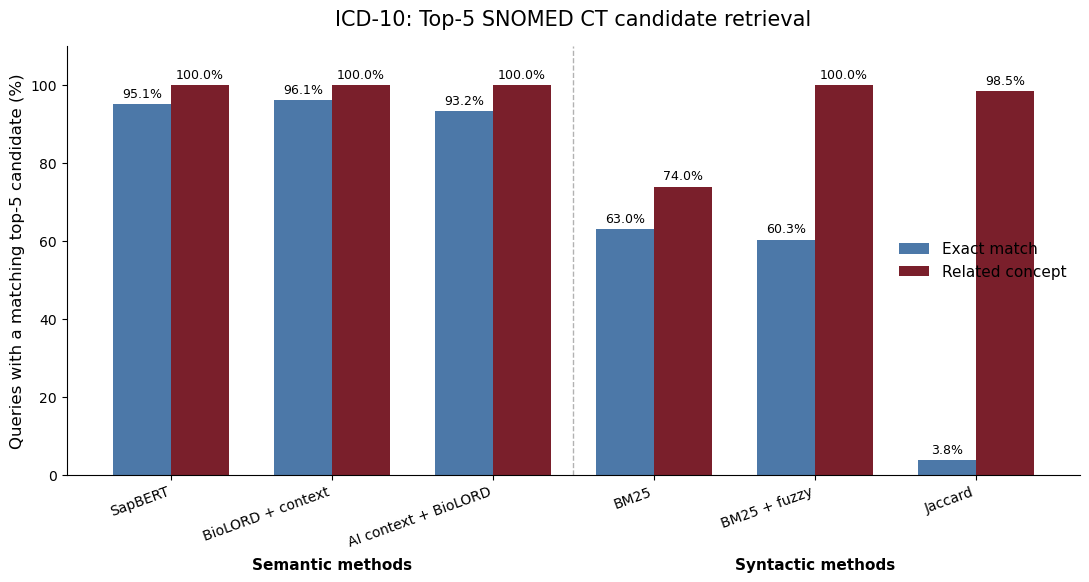

In [16]:
method_order = ["algorithm_1", "algorithm_2", "algorithm_ai", "multi_match", "elastic_fuzzy", "jaccard"]

plot_data = method_scores_icd10.set_index("method").loc[method_order].reset_index()

x = np.arange(len(plot_data))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 6))

bars_exact = ax.bar(x - width / 2, plot_data["exact_hit@5"] * 100, width, label="Exact match", color="#4C78A8")
bars_related = ax.bar(x + width / 2, plot_data["related_hit@5"] * 100, width, label="Related concept", color="#7A1F2B")

ax.set_ylabel("Queries with a matching top-5 candidate (%)", fontsize=12)
ax.set_title("ICD-10: Top-5 SNOMED CT candidate retrieval", fontsize=15, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(plot_data["label"], rotation=20, ha="right")

for bars in (bars_exact, bars_related):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 1, f"{height:.1f}%", ha="center", va="bottom", fontsize=9)

# Semantic / syntactic separator
ax.axvline(2.5, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.text(1, -0.22, "Semantic methods", transform=ax.get_xaxis_transform(), ha="center", fontsize=11, fontweight="bold")
ax.text(4, -0.22, "Syntactic methods", transform=ax.get_xaxis_transform(), ha="center", fontsize=11, fontweight="bold")

ax.legend(frameon=False, fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, max(plot_data["exact_hit@5"].max(), plot_data["related_hit@5"].max()) * 100 + 10)

plt.tight_layout()

chart_path = config.OUTPUT_DIR / "poster_method_comparison_icd10.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
print(f"Saved: {chart_path}")
plt.show()